# 08 — Closed-form pharmacokinetics and event-aware ODE simulation

This notebook compares PyMixEF's one-compartment IV-bolus closed form with its event-aware ODE solver, then explores finite infusion, oral absorption, parameter sensitivity, and residual-error variance.

## Objectives

- Evaluate supported closed-form one-compartment concentration functions.
- Simulate a bolus dose as an exact ODE event-time discontinuity.
- Cross-check two independent calculation paths on the same model.
- Request a finite-difference parameter sensitivity.
- Distinguish structural prediction from an observation-error model.

In [1]:
import logging

import numpy as np

from pymixef.pharmacometrics import (
    combined,
    one_compartment_infusion,
    one_compartment_iv_bolus,
    one_compartment_oral,
    simulate_ode,
)

# Keep a fresh-kernel run free of Matplotlib's one-time font-cache status message.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import matplotlib.pyplot as plt  # noqa: E402

PLOT_COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "black": "#222222",
}

## Closed-form IV bolus

For a one-compartment IV bolus, concentration is `(dose / volume) * exp(-(clearance / volume) * time)`. Amount, clearance, volume, and time can use any mutually consistent units.

In [2]:
times = np.linspace(0.0, 12.0, 25)
dose = 100.0
parameters = {"CL": 5.0, "V": 20.0}

closed_form = one_compartment_iv_bolus(
    times,
    dose=dose,
    clearance=parameters["CL"],
    volume=parameters["V"],
)

[
    {"time": float(time), "concentration": float(value)}
    for time, value in zip(times[:6], np.round(closed_form[:6], 6), strict=True)
]

[{'time': 0.0, 'concentration': 5.0},
 {'time': 0.5, 'concentration': 4.412485},
 {'time': 1.0, 'concentration': 3.894004},
 {'time': 1.5, 'concentration': 3.436446},
 {'time': 2.0, 'concentration': 3.032653},
 {'time': 2.5, 'concentration': 2.676307}]

## The same model as an ODE

The ODE state is central amount, not concentration. The event manager adds the dose at time zero; the right-hand side handles elimination. The concentration is amount divided by volume.

In [3]:
events = [{"ID": "S1", "TIME": 0.0, "EVID": 1, "AMT": dose, "CMT": "central"}]


def elimination_rhs(time, state, context):
    del time
    rate_constant = context.parameters["CL"] / context.parameters["V"]
    return [-rate_constant * state[0]]


ode_result = simulate_ode(
    elimination_rhs,
    [0.0],
    events,
    t_eval=times,
    parameters=parameters,
    state_names=["central"],
    sensitivity_parameters=["CL"],
)
ode_concentration = ode_result.state("central") / parameters["V"]
maximum_difference = float(np.max(np.abs(ode_concentration - closed_form)))
assert ode_result.metadata.success
assert maximum_difference < 1e-7, "ODE and closed form should agree to solver tolerance"

{
    "maximum_absolute_difference": maximum_difference,
    "solver_success": ode_result.metadata.success,
    "agreement_check": "passed",
    "solver_segments": ode_result.metadata.segments,
    "event_actions": ode_result.metadata.event_actions,
}

{'maximum_absolute_difference': 2.3192008313799306e-09,
 'solver_success': True,
 'agreement_check': 'passed',
 'solver_segments': 24,
 'event_actions': 1}

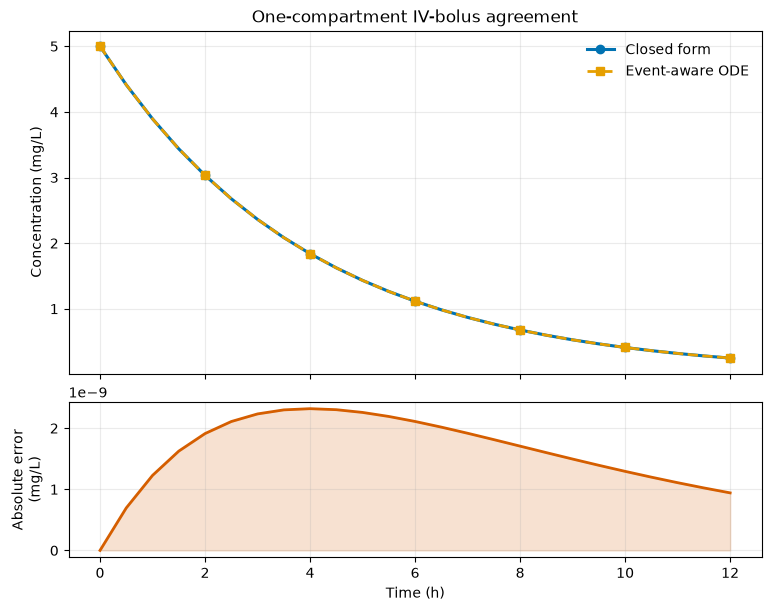

In [4]:
absolute_error = np.abs(ode_concentration - closed_form)
fig, (ax_curve, ax_error) = plt.subplots(
    2,
    1,
    figsize=(7.6, 6.0),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.0]},
    constrained_layout=True,
)
ax_curve.plot(
    times,
    closed_form,
    color=PLOT_COLORS["blue"],
    linewidth=2.2,
    marker="o",
    markevery=4,
    label="Closed form",
)
ax_curve.plot(
    times,
    ode_concentration,
    color=PLOT_COLORS["orange"],
    linewidth=2.0,
    linestyle="--",
    marker="s",
    markevery=4,
    label="Event-aware ODE",
)
ax_curve.set_ylabel("Concentration (mg/L)")
ax_curve.set_title("One-compartment IV-bolus agreement")
ax_curve.legend(frameon=False)
ax_curve.grid(alpha=0.25)

ax_error.plot(times, absolute_error, color=PLOT_COLORS["vermillion"], linewidth=2.0)
ax_error.fill_between(times, 0.0, absolute_error, color=PLOT_COLORS["vermillion"], alpha=0.18)
ax_error.set_xlabel("Time (h)")
ax_error.set_ylabel("Absolute error\n(mg/L)")
ax_error.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax_error.grid(alpha=0.25)
plt.show()

The two concentration curves overlap at the plotted scale, while the lower panel exposes the small numerical discrepancy. The error remains below the asserted solver tolerance across all sampled times.

Agreement to numerical ODE tolerance is a useful internal cross-check. It is not independent external validation because both paths are implemented in the same package.

## Clearance sensitivity

The archived sensitivity below is the derivative of central amount with respect to clearance. A negative derivative after time zero matches the scientific expectation that greater clearance lowers later exposure.

In [5]:
amount_sensitivity_to_cl = ode_result.sensitivity("central", "CL")
[
    {"time": float(time), "d_amount_d_cl": float(value)}
    for time, value in zip(times[:8], np.round(amount_sensitivity_to_cl[:8], 6), strict=True)
]

[{'time': 0.0, 'd_amount_d_cl': 0.0},
 {'time': 0.5, 'd_amount_d_cl': -2.206242},
 {'time': 1.0, 'd_amount_d_cl': -3.894004},
 {'time': 1.5, 'd_amount_d_cl': -5.15467},
 {'time': 2.0, 'd_amount_d_cl': -6.065307},
 {'time': 2.5, 'd_amount_d_cl': -6.690768},
 {'time': 3.0, 'd_amount_d_cl': -7.085498},
 {'time': 3.5, 'd_amount_d_cl': -7.295085}]

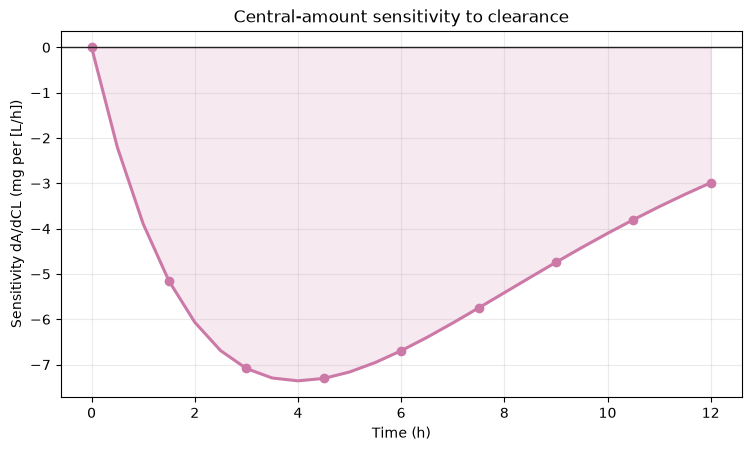

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 4.4), constrained_layout=True)
ax.plot(
    times,
    amount_sensitivity_to_cl,
    color=PLOT_COLORS["purple"],
    linewidth=2.2,
    marker="o",
    markevery=3,
)
ax.fill_between(
    times,
    0.0,
    amount_sensitivity_to_cl,
    color=PLOT_COLORS["purple"],
    alpha=0.16,
)
ax.axhline(0.0, color=PLOT_COLORS["black"], linewidth=1.0)
ax.set_xlabel("Time (h)")
ax.set_ylabel("Sensitivity dA/dCL (mg per [L/h])")
ax.set_title("Central-amount sensitivity to clearance")
ax.grid(alpha=0.25)
plt.show()

Sensitivity is zero at the instant of dosing and negative thereafter: increasing clearance reduces central amount. Its time-varying magnitude identifies when the trajectory is most responsive to a small clearance perturbation.

## Infusion and oral routes

The infusion helper uses a finite constant rate; the oral helper uses first-order absorption. These are structural concentration predictions without measurement noise.

In [7]:
infusion = one_compartment_infusion(
    times,
    dose=100.0,
    duration=2.0,
    clearance=parameters["CL"],
    volume=parameters["V"],
)
oral = one_compartment_oral(
    times,
    dose=100.0,
    clearance=parameters["CL"],
    volume=parameters["V"],
    absorption_rate=1.2,
)

{
    "bolus_peak": float(np.max(closed_form)),
    "infusion_peak": float(np.max(infusion)),
    "oral_peak": float(np.max(oral)),
    "oral_peak_time": float(times[np.argmax(oral)]),
}

{'bolus_peak': 5.0,
 'infusion_peak': 3.9346934028736658,
 'oral_peak': 3.296781414122436,
 'oral_peak_time': 1.5}

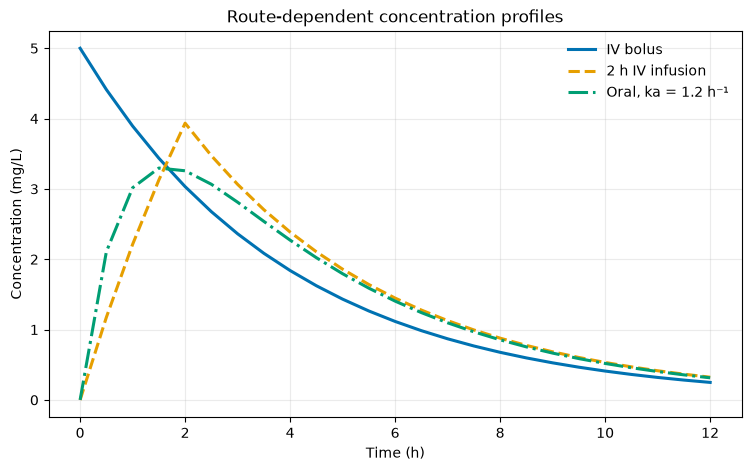

In [8]:
fig, ax = plt.subplots(figsize=(7.4, 4.6), constrained_layout=True)
route_series = (
    ("IV bolus", closed_form, PLOT_COLORS["blue"], "-"),
    ("2 h IV infusion", infusion, PLOT_COLORS["orange"], "--"),
    ("Oral, ka = 1.2 h⁻¹", oral, PLOT_COLORS["green"], "-."),
)
for label, concentration, color, linestyle in route_series:
    ax.plot(
        times,
        concentration,
        color=color,
        linestyle=linestyle,
        linewidth=2.2,
        label=label,
    )
ax.set_xlabel("Time (h)")
ax.set_ylabel("Concentration (mg/L)")
ax.set_title("Route-dependent concentration profiles")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

The bolus produces an immediate peak, the finite infusion lowers and delays that peak, and first-order oral absorption shifts the maximum later still. These contrasts arise from input kinetics; clearance and volume are otherwise held fixed.

## Observation-error variance

A combined error model has additive and prediction-proportional variance components. Calling `variance` does not fit those components; it evaluates a declared error model at supplied predictions.

In [9]:
observation_error = combined(additive_sigma=0.10, proportional_sigma=0.15)
variance = observation_error.variance(closed_form)
[
    {
        "time": float(time),
        "prediction": float(prediction),
        "variance": float(error_variance),
    }
    for time, prediction, error_variance in zip(
        times[:6],
        np.round(closed_form[:6], 6),
        np.round(variance[:6], 6),
        strict=True,
    )
]

[{'time': 0.0, 'prediction': 5.0, 'variance': 0.5725},
 {'time': 0.5, 'prediction': 4.412485, 'variance': 0.448075},
 {'time': 1.0, 'prediction': 3.894004, 'variance': 0.351173},
 {'time': 1.5, 'prediction': 3.436446, 'variance': 0.275706},
 {'time': 2.0, 'prediction': 3.032653, 'variance': 0.216932},
 {'time': 2.5, 'prediction': 2.676307, 'variance': 0.171159}]

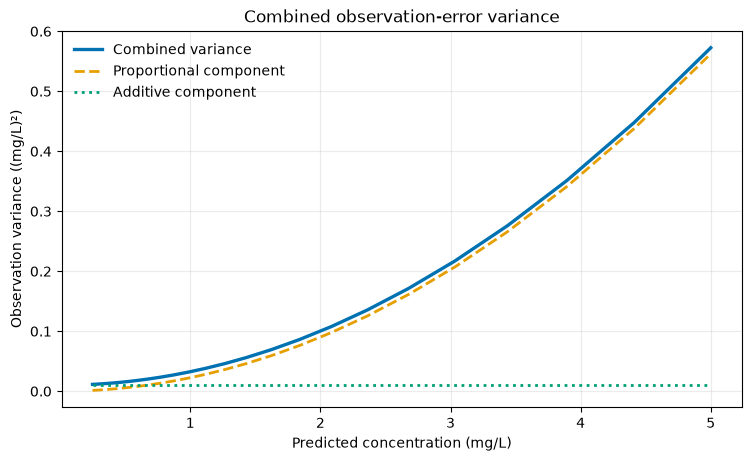

In [10]:
additive_variance = np.full_like(closed_form, 0.10**2)
proportional_variance = (0.15 * closed_form) ** 2
concentration_order = np.argsort(closed_form)

fig, ax = plt.subplots(figsize=(7.4, 4.5), constrained_layout=True)
ax.plot(
    closed_form[concentration_order],
    variance[concentration_order],
    color=PLOT_COLORS["blue"],
    linewidth=2.4,
    label="Combined variance",
)
ax.plot(
    closed_form[concentration_order],
    proportional_variance[concentration_order],
    color=PLOT_COLORS["orange"],
    linewidth=2.0,
    linestyle="--",
    label="Proportional component",
)
ax.plot(
    closed_form[concentration_order],
    additive_variance[concentration_order],
    color=PLOT_COLORS["green"],
    linewidth=2.0,
    linestyle=":",
    label="Additive component",
)
ax.set_xlabel("Predicted concentration (mg/L)")
ax.set_ylabel("Observation variance ((mg/L)²)")
ax.set_title("Combined observation-error variance")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

The proportional component grows quadratically with predicted concentration, whereas the additive component supplies a constant variance floor. The combined curve is a declared measurement model, not an estimate from these simulated predictions.

## Scope note

This showcase simulates known individual parameters under linear one-compartment kinetics with mutually consistent units. ODE sensitivities use finite differences, and the capability report documents the remaining implementation limitations; closed-form agreement is valuable regression evidence rather than independent external parity.

## Exercises

1. Double clearance and explain changes in half-life and exposure.
2. Add a second bolus event at 12 hours and extend `t_eval` to 24 hours.
3. Build an infusion event table and compare event-aware ODE output with `one_compartment_infusion`.
4. Change absorption rate toward the elimination rate and observe the stable limiting behavior of the oral helper.